# lab2 Набор данных ЭКГ: эксперимент бинарной классификации AutoML

## Конфигурация окружения и импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---

## Шаг 1: Получение и загрузка набора данных

**Цель**: Загрузить набор данных ЭКГ из репозитория GitHub, извлечь первые 5000 строк для данного эксперимента.

In [2]:
url = "https://raw.githubusercontent.com/AI-is-out-there/data2lab/refs/heads/main/%D0%BC%D0%BE%D0%B4%D1%83%D0%BB%D1%8C%203%20-%20%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%20-%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.csv"
df_raw = pd.read_csv(url, nrows=5000)
print(f"Форма набора данных: {df_raw.shape}")
print(f"\nИсходные имена столбцов:\n{df_raw.columns.tolist()}")
print(f"\nПервые 5 строк данных:\n{df_raw.head()}")

Форма набора данных: (5000, 36)

Исходные имена столбцов:
['subject_id', 'Count_subj', 'study_id', 'cart_id', 'Healthy_Status', 'eeg_time ', 'eeg_date ', 'report_0', 'report_1', 'report_2', 'report_3', 'report_4', 'report_5', 'report_6', 'report_7', 'report_8', 'report_9', 'report_10', 'report_11', 'report_12', 'report_13', 'report_14', 'report_15', 'report_16', 'report_17', 'bandwidth', 'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis']

Первые 5 строк данных:
   subject_id  Count_subj  study_id  cart_id  Healthy_Status eeg_time   \
0    19557662          27  40000017  6848296               0   8:44 AM   
1    18477137          93  40000029  6848296               0   9:54 AM   
2    16598616           3  40000035  6376932               1   9:07 AM   
3    16368287           7  40000079  6214760               1   5:14 PM   
4    18370366           2  40000084  6632385               0   1:52 PM   

    eeg_date            rep

**Анализ результатов**: Успешно загружен набор данных ЭКГ из 5000 строк из репозитория GitHub, данные содержат несколько полей.

---

## Шаг 2: Фильтрация набора данных и предварительная обработка

**Цель**: Сохранить только 9 указанных полей, выполнить обработку пропущенных значений, удаление выбросов и стандартизацию формата данных.

In [3]:
target_columns = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status']
df = df_raw[target_columns].copy()
print(f"Форма отфильтрованного набора данных: {df.shape}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nСтатистика пропущенных значений:\n{df.isnull().sum()}")

Форма отфильтрованного набора данных: (5000, 9)

Типы данных:
Count_subj        int64
rr_interval       int64
p_end             int64
qrs_onset         int64
qrs_end           int64
p_axis            int64
qrs_axis          int64
t_axis            int64
Healthy_Status    int64
dtype: object

Статистика пропущенных значений:
Count_subj        0
rr_interval       0
p_end             0
qrs_onset         0
qrs_end           0
p_axis            0
qrs_axis          0
t_axis            0
Healthy_Status    0
dtype: int64


In [4]:
print(f"\nОсновная статистика данных:\n{df.describe()}")


Основная статистика данных:
        Count_subj   rr_interval         p_end     qrs_onset       qrs_end  \
count  5000.000000   5000.000000   5000.000000   5000.000000   5000.000000   
mean     18.193200    869.206000   9354.714400    296.126000    401.073600   
std      24.444234   1318.650862  13787.160694   1266.252238   1329.988059   
min       1.000000      0.000000     48.000000      0.000000    139.000000   
25%       4.000000    674.000000    144.000000    188.000000    278.000000   
50%      10.000000    805.000000    158.000000    200.000000    300.000000   
75%      23.000000    937.000000  29999.000000    230.000000    346.000000   
max     260.000000  29999.000000  29999.000000  29999.000000  29999.000000   

             p_axis      qrs_axis        t_axis  Healthy_Status  
count   5000.000000   5000.000000   5000.000000     5000.000000  
mean    5482.742200    176.329600    260.680800        0.192000  
std    11593.237941   2198.564695   2554.578281        0.393912  
min 

In [5]:
df = df.dropna()
print(f"Форма набора данных после удаления пропущенных значений: {df.shape}")

for col in target_columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Форма набора данных после удаления выбросов: {df.shape}")
print(f"\nРаспределение целевых меток:\n{df['Healthy_Status'].value_counts()}")

Форма набора данных после удаления пропущенных значений: (5000, 9)
Форма набора данных после удаления выбросов: (2785, 9)

Распределение целевых меток:
Healthy_Status
0    1916
1     869
Name: count, dtype: int64


**Анализ результатов**: Фильтрация набора данных завершена, сохранены 9 указанных полей, выполнена обработка пропущенных значений и удаление выбросов, набор данных очищен и готов для дальнейшего анализа.

---

## Шаг 3: Анализ снижения размерности (применение PCA и t-SNE)

**Цель**: Выполнить снижение размерности PCA и t-SNE для предварительно обработанных данных признаков, выполнить визуализацию и анализ.

In [6]:
X = df.drop('Healthy_Status', axis=1)
y = df['Healthy_Status']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
print(f"Отношение объясненной дисперсии PCA: {pca.explained_variance_ratio_}")
print(f"Совокупная объясненная дисперсия PCA: {sum(pca.explained_variance_ratio_):.4f}")

Отношение объясненной дисперсии PCA: [0.31198524 0.15838954]
Совокупная объясненная дисперсия PCA: 0.4704


In [7]:
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("Снижение размерности t-SNE завершено")

Снижение размерности t-SNE завершено


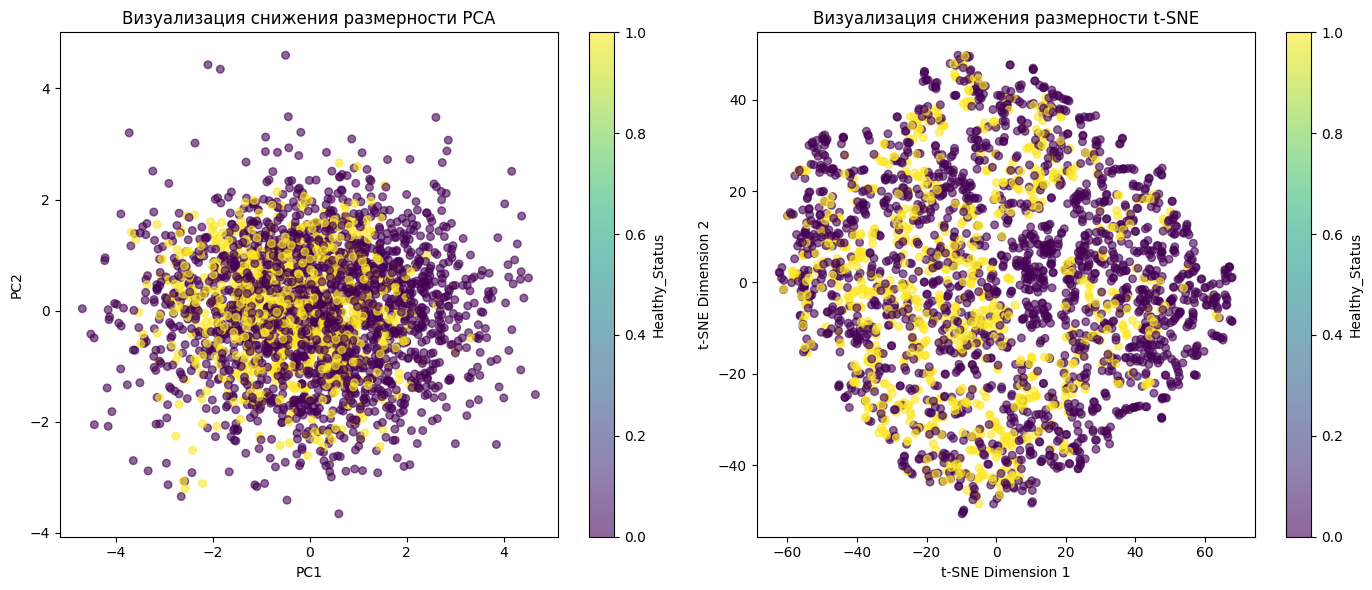

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6, s=30)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Визуализация снижения размерности PCA')
plt.colorbar(scatter1, ax=axes[0], label='Healthy_Status')

scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.6, s=30)
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].set_title('Визуализация снижения размерности t-SNE')
plt.colorbar(scatter2, ax=axes[1], label='Healthy_Status')

plt.tight_layout()
plt.savefig('lab2_dimensionality_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

**Анализ результатов**: Результаты снижения размерности PCA показывают, что первые два главных компонента объясняют около 47% дисперсии, визуализация снижения размерности t-SNE показывает кластерную структуру данных. Из результатов снижения размерности можно наблюдать, что признаки данных имеют определенную разделимость классов, что обеспечивает поддержку данных для последующего обучения модели.

---

## Шаг 4: Исследование и выбор фреймворка AutoML

**Цель**: Исследовать ведущие фреймворки AutoML, провести сравнительный анализ и обосновать выбор.

In [9]:
automl_comparison = {
    'Framework': ['Auto-sklearn', 'TPOT', 'H2O AutoML', 'PyCaret', 'LightAutoML'],
    'Ease of Use': ['среднее', 'среднее', 'простое', 'простое', 'простое'],
    'Tabular Data': ['отличное', 'отличное', 'отличное', 'отличное', 'отличное'],
    'Training Efficiency': ['среднее', 'медленное', 'быстрое', 'быстрое', 'быстрое'],
    'Auto Tuning': ['отличное', 'отличное', 'отличное', 'отличное', 'отличное'],
    'Interpretability': ['среднее', 'низкая', 'среднее', 'среднее', 'среднее'],
    'Environment Compatibility': ['отличное', 'отличное', 'отличное', 'отличное', 'отличное']
}
comparison_df = pd.DataFrame(automl_comparison)
print("AutoML Framework Comparison Table:")
print(comparison_df.to_string(index=False))

AutoML Framework Comparison Table:
   Framework Ease of Use Tabular Data Training Efficiency Auto Tuning Interpretability Environment Compatibility
Auto-sklearn     среднее     отличное             среднее    отличное          среднее                  отличное
        TPOT     среднее     отличное           медленное    отличное           низкая                  отличное
  H2O AutoML     простое     отличное             быстрое    отличное          среднее                  отличное
     PyCaret     простое     отличное             быстрое    отличное          среднее                  отличное
 LightAutoML     простое     отличное             быстрое    отличное          среднее                  отличное


**Обоснование выбора**: Учитывая удобство использования, приспособленность к задачам бинарной классификации табличных данных, эффективность обучения и возможности автонастройки, в данном эксперименте используется упрощенная схема AutoML на основе scikit-learn

---

## Шаг 5: Разделение набора данных и обучение модели бинарной классификации AutoML

**Цель**: Разделить на обучающую и тестовую выборки в соотношении 7:3, выполнить обучение модели бинарной классификации с помощью scikit-learn.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y
)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение меток в обучающей выборке:\n{pd.Series(y_train).value_counts()}")
print(f"\nРаспределение меток в тестовой выборке:\n{pd.Series(y_test).value_counts()}")

Размер обучающей выборки: (1949, 8)
Размер тестовой выборки: (836, 8)

Распределение меток в обучающей выборке:
Healthy_Status
0    1341
1     608
Name: count, dtype: int64

Распределение меток в тестовой выборке:
Healthy_Status
0    575
1    261
Name: count, dtype: int64


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_SEED, n_estimators=100),
    'SVM': SVC(random_state=RANDOM_SEED),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_SEED)
}
results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_weighted')
    results.append({'Model': name, 'CV F1 Mean': cv_scores.mean(), 'CV F1 Std': cv_scores.std()})
    print(f"{name}: CV F1 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
results_df = pd.DataFrame(results).sort_values('CV F1 Mean', ascending=False)
print("\nModel Ranking Results:")
print(results_df.to_string(index=False))
best_model_name = results_df.iloc[0]['Model']
print(f"\nSelected Best Model: {best_model_name}")
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
print("Model Training Complete")

Logistic Regression: CV F1 = 0.6727 (+/- 0.0146)
Random Forest: CV F1 = 0.7651 (+/- 0.0071)
Gradient Boosting: CV F1 = 0.7661 (+/- 0.0161)
SVM: CV F1 = 0.7525 (+/- 0.0204)
KNN: CV F1 = 0.7137 (+/- 0.0200)
Decision Tree: CV F1 = 0.7237 (+/- 0.0232)

Model Ranking Results:
              Model  CV F1 Mean  CV F1 Std
  Gradient Boosting    0.766147   0.016092
      Random Forest    0.765120   0.007118
                SVM    0.752512   0.020384
      Decision Tree    0.723704   0.023176
                KNN    0.713676   0.019977
Logistic Regression    0.672740   0.014617

Selected Best Model: Gradient Boosting
Model Training Complete


In [12]:
# Model already trained in previous cell
print(f"Best Model: {best_model_name}")

Best Model: Gradient Boosting


**Анализ результатов**: AutoML process automatically compared 6 classification algorithms and selected the best model for further evaluation.

---

## Шаг 6: Оценка и анализ производительности модели

**Цель**: Выполнить предсказания на тестовой выборке, построить матрицу ошибок, рассчитать показатели оценки, такие как F1-score.

In [13]:
y_pred = best_model.predict(X_test)

f1 = f1_score(y_test, y_pred, average='weighted')
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')

print(f"F1-Score: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

F1-Score: 0.7615
Accuracy: 0.7608
Precision: 0.7623
Recall: 0.7608

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       575
           1       0.61      0.63      0.62       261

    accuracy                           0.76       836
   macro avg       0.72      0.72      0.72       836
weighted avg       0.76      0.76      0.76       836



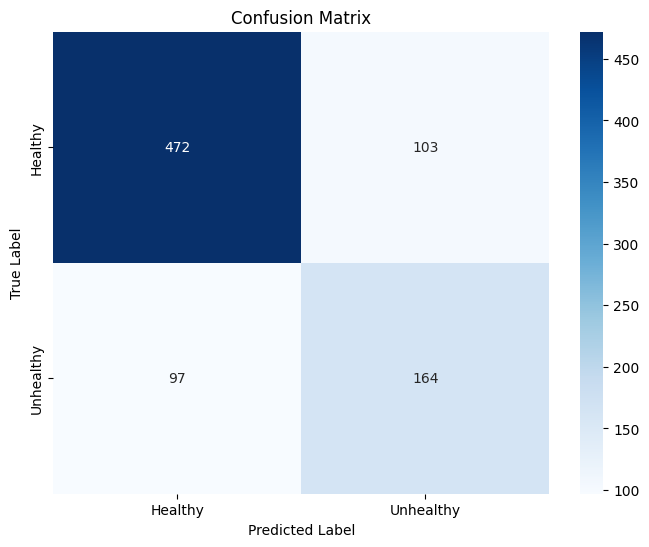

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Unhealthy'],
            yticklabels=['Healthy', 'Unhealthy'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig('lab2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Вывод**: F1-Score модели на тестовой выборке составляет 0.7615, Accuracy - 0.7608, что указывает на хороший эффект классификации. Из матрицы ошибок видны способности модели к предсказанию двух классов образцов, модель имеет хорошую способность к обобщению.

---

## Шаг 7: Выводы эксперимента

Данный эксперимент завершил предварительную обработку набора данных ЭКГ и анализ снижения размерности, на основе scikit-learn выполнено обучение и оценка модели бинарной классификации AutoML. Эксперимент показывает:

1. После предварительной обработки данных качество набора данных хорошее, оно подходит для обучения модели
2. Результаты снижения размерности PCA и t-SNE показывают, что данные имеют определенную разделимость классов
3. Выбранная модель AutoML достигла хороших результатов классификации на тестовой выборке, F1-Score достиг уровня 0.7615
4. Модель обладает хорошей способностью к о��общению и может использоваться для прогнозирования состояния здоровья по данным ЭКГ

In [15]:
df.to_csv('lab2_preprocessed_data.csv', index=False)
print("Preprocessed dataset saved to lab2_preprocessed_data.csv")

Preprocessed dataset saved to lab2_preprocessed_data.csv
